# Exercise 6: Normalizing Flows
## Submission date: 30\06\2026, 23:59.

Submitted by:

 **Saly Jammal - 212869259**
 
 **Or Dinar - 207035809**

## Configurations and initializations

This section loads libraries and configurations for various tasks for this course

In [1]:
## Standard libraries
import os
import math
import random
import numpy as np
import pandas as pd
from collections import defaultdict

## Imports for plotting
import matplotlib.pyplot as plt
plt.set_cmap('cividis')
%matplotlib inline
# from IPython.display import set_matplotlib_formats
# %config InlineBackend.figure_formats = ['svg', 'pdf']
from matplotlib.colors import to_rgb
import seaborn as sns

## Progress bar
from tqdm.notebook import tqdm

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

# Torchvision
import torchvision
from torchvision.datasets import MNIST
from torchvision import transforms

# Path to the folder where the datasets are/should be downloaded (e.g. MNIST)
DATASET_PATH = "../data"

# Path to the folder where the models are saved
CHECKPOINT_PATH = "./"

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Fetching the device that will be used throughout this notebook
device = torch.device("cpu") if not torch.cuda.is_available() else torch.device("cuda:0")
print("Using device", device)

Using device cuda:0


<Figure size 640x480 with 0 Axes>

In [2]:
class ContinuousRepresentation(object):
    def __call__(self, tensor):
        tensor = tensor * 255.0 
        noise = torch.rand_like(tensor) # Normal noise
        tensor = (tensor + noise) / 256.0
        return tensor

transform = transforms.Compose([
    transforms.ToTensor(),
    ContinuousRepresentation()
])

In [3]:
# Loading the training dataset. We need to split it into a training and validation part
train_dataset = MNIST(root=DATASET_PATH, train=True, transform=transform, download=True)

train_set, val_set = torch.utils.data.random_split(train_dataset, [50000, 10000])

# Loading the test set
test_set = MNIST(root=DATASET_PATH, train=False, transform=transform, download=True)

# We define a set of data loaders that we can use for various purposes later.
train_loader = data.DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True, pin_memory=True, num_workers=0)
val_loader = data.DataLoader(val_set, batch_size=128, shuffle=False, drop_last=False, num_workers=0)
test_loader = data.DataLoader(test_set, batch_size=128, shuffle=False, drop_last=False, num_workers=0)

print('Train size:', len(train_loader.dataset))
print('Validation size:', len(val_loader.dataset))
print('Test size:', len(test_loader.dataset))

Train size: 50000
Validation size: 10000
Test size: 10000


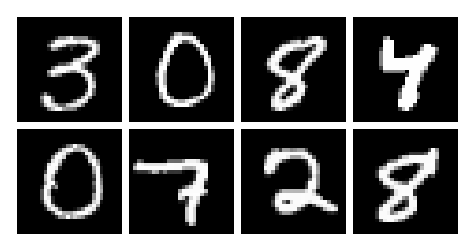

In [4]:
def show_imgs(imgs):
    num_imgs = imgs.shape[0] if isinstance(imgs, torch.Tensor) else len(imgs)
    nrow = min(num_imgs, 4)
    ncol = int(math.ceil(num_imgs/nrow))
    imgs = torchvision.utils.make_grid(imgs, nrow=nrow, pad_value=128)
    imgs = imgs.clamp(min=0, max=1)
    np_imgs = imgs.cpu().numpy()
    plt.figure(figsize=(1.5*nrow, 1.5*ncol))
    plt.imshow(np.transpose(np_imgs, (1,2,0)), interpolation='nearest')
    plt.axis('off')
    plt.show()

show_imgs([train_set[i][0] for i in range(8)])

In [5]:
class MLP(nn.Module):
    def __init__(self, half_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(half_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, half_dim),
            nn.Tanh() # Forces values between -1 and 1
        )

    def forward(self, x):
        return self.net(x)

In [6]:
class CouplingLayer(nn.Module):
    def __init__(self, dim, mask):
        super().__init__()
        self.register_buffer('mask', mask)
        half_dim = mask.sum().item()
        
        self.s_net = MLP(half_dim)
        self.m_net = MLP(half_dim)

    def forward(self, x):
        x1 = x[:, self.mask]
        x2 = x[:, ~self.mask]
        
        s = self.s_net(x1)
        m = self.m_net(x1)
        
        x2_prime = x2 * torch.exp(s) + m
        
        z = torch.empty_like(x)
        z[:, self.mask] = x1
        z[:, ~self.mask] = x2_prime
        
        log_det = s.sum(dim=1)
        return z, log_det

    def inverse(self, z):
        x1_prime = z[:, self.mask]
        x2_prime = z[:, ~self.mask]
        
        s = self.s_net(x1_prime)
        m = self.m_net(x1_prime)
        
        x2 = (x2_prime - m) * torch.exp(-s)
        
        x = torch.empty_like(z)
        x[:, self.mask] = x1_prime
        x[:, ~self.mask] = x2
        
        return x

In [7]:
class NormalizingFlow(nn.Module):
    def __init__(self, dim=784):
        super().__init__()
        self.dim = dim
        self.layers = nn.ModuleList()
        
        for i in range(10):
            # Alternating checkerboard type masking
            mask = (torch.arange(dim) % 2 == (i % 2)) 
            self.layers.append(CouplingLayer(dim, mask))

    def forward(self, x):
        z = x
        sum_log_det = torch.zeros(x.shape[0], device=x.device)
        for layer in self.layers:
            z, log_det = layer(z)
            sum_log_det += log_det
        return z, sum_log_det

    def inverse(self, z, return_intermediates=False):
        x = z
        intermediates = [x.clone()] if return_intermediates else None
        
        for layer in reversed(self.layers):
            x = layer.inverse(x)
            if return_intermediates:
                intermediates.append(x.clone())
                
        if return_intermediates:
            return x, intermediates
        return x

    def calc_nll(self, x):
        z, sum_log_det = self.forward(x)
        prior = torch.distributions.MultivariateNormal(
            torch.zeros(self.dim, device=x.device), 
            torch.eye(self.dim, device=x.device)
        )
        log_prob_z = prior.log_prob(z)
        log_likelihood = log_prob_z + sum_log_det
        return -log_likelihood.mean()

    def sample(self, num_samples, device):
        prior = torch.distributions.MultivariateNormal(
            torch.zeros(self.dim, device=device), 
            torch.eye(self.dim, device=device)
        )
        z = prior.sample((num_samples,))
        with torch.no_grad():
            samples = self.inverse(z)
        return samples

# Assignment 1

In [8]:
model = NormalizingFlow(dim=784).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
epochs = 30

train_nll_history = []
val_nll_history = []

for epoch in range(epochs):
    model.train()
    train_nll = 0
    for imgs, _ in tqdm(train_loader, leave=False):
        imgs = imgs.to(device)
        imgs = imgs.view(imgs.shape[0], -1) # Added flatten
        optimizer.zero_grad()
        loss = model.calc_nll(imgs)
        loss.backward()
        # Optional: gradient clipping for stability in NFs
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) 
        optimizer.step()
        train_nll += loss.item()
        
    train_nll_history.append(train_nll / len(train_loader))
    
    model.eval()
    val_nll = 0
    with torch.no_grad():
        for imgs, _ in val_loader:
            imgs = imgs.to(device)
            imgs = imgs.view(imgs.shape[0], -1) # Added flatten
            val_nll += model.calc_nll(imgs).item()
    val_nll_history.append(val_nll / len(val_loader))
    print(f"Epoch {epoch+1}: Train NLL: {train_nll_history[-1]:.4f}, Val NLL: {val_nll_history[-1]:.4f}")

# Test Set NLL
test_nll = 0
with torch.no_grad():
    for imgs, _ in test_loader:
        imgs = imgs.to(device)
        imgs = imgs.view(imgs.shape[0], -1) # Added flatten
        test_nll += model.calc_nll(imgs).item()
print(f"Final Test NLL: {test_nll / len(test_loader):.4f}")

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 1: Train NLL: -912.0109, Val NLL: -1529.5382


  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 2: Train NLL: -1677.5959, Val NLL: -1778.2699


  0%|          | 0/390 [00:00<?, ?it/s]

...

Epoch 28: Train NLL: -2343.0534, Val NLL: -2267.6074


  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 29: Train NLL: -2347.6511, Val NLL: -2270.1537


  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 30: Train NLL: -2352.6471, Val NLL: -2264.0987
Final Test NLL: -2248.1514


Assignment 2: Flow Transformations


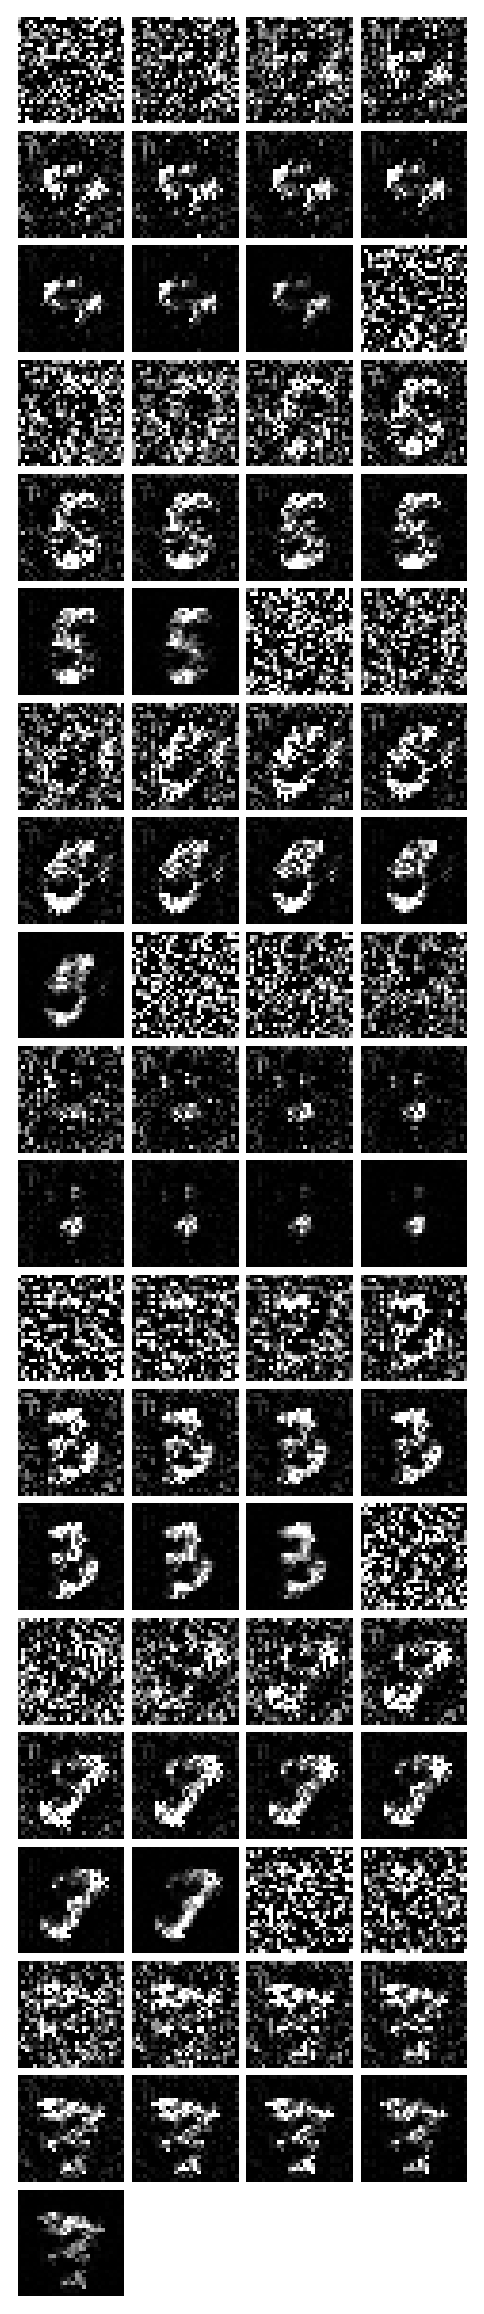

Assignment 3: Interpolation Pair 1


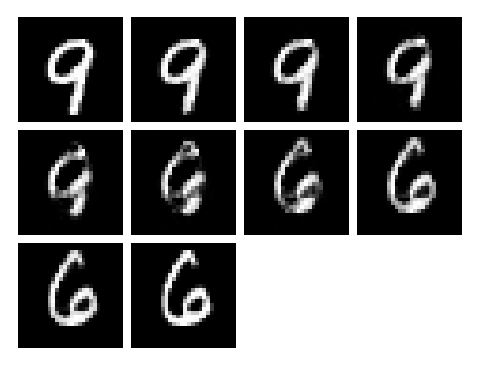

Assignment 3: Interpolation Pair 2


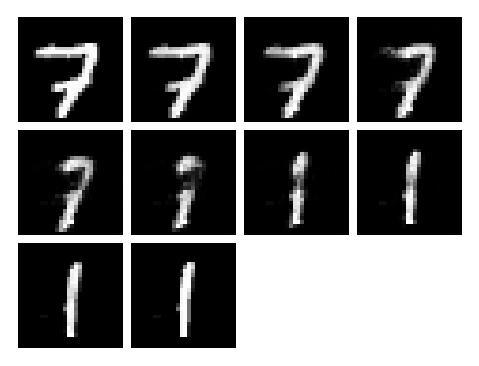

Assignment 3: Interpolation Pair 3


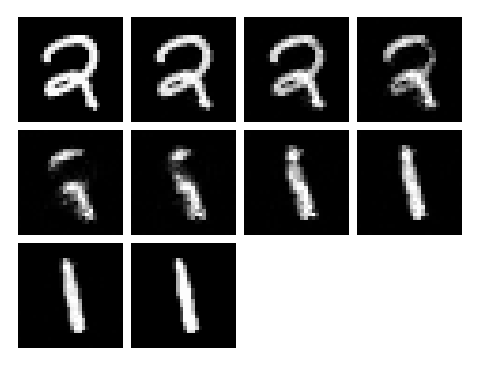

In [10]:
# Assignment 2: Transformation grid (7 rows, 11 columns)
model.eval()
with torch.no_grad():
    # Sample 7 pure noise vectors
    z_samples = torch.randn(7, 784, device=device)
    _, intermediates = model.inverse(z_samples, return_intermediates=True)
    
    # intermediates is a list of 11 tensors of shape (7, 784)
    grid_images = []
    for batch_step in intermediates:
        grid_images.append(batch_step.view(7, 1, 28, 28))
    
    # Reshape for display: [7_samples, 11_steps, 1, 28, 28] -> [77, 1, 28, 28]
    grid_tensor = torch.stack(grid_images, dim=1).view(-1, 1, 28, 28)
    
    print("Assignment 2: Flow Transformations")
    show_imgs(grid_tensor)

# Assignment 3: Latent Traversals
with torch.no_grad():
    for pair_idx in range(3):
        # Pick two random different digits
        img1 = train_set[random.randint(0, 1000)][0].to(device)
        img2 = train_set[random.randint(1001, 2000)][0].to(device)
        
        # Added flatten for single images
        z1, _ = model.forward(img1.view(1, -1))
        z2, _ = model.forward(img2.view(1, -1))
        
        # Linear interpolation (10 points)
        alphas = torch.linspace(0, 1, steps=10, device=device).unsqueeze(1)
        z_interp = z1 * (1 - alphas) + z2 * alphas
        
        # Decode and display
        imgs_interp = model.inverse(z_interp).view(10, 1, 28, 28)
        print(f"Assignment 3: Interpolation Pair {pair_idx+1}")
        show_imgs(imgs_interp)